# Heston/GARCH Mixture Experiment

Train AADH and SDH on different Heston/GARCH path mixtures, then test both models on every mixture.

In [8]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from training.train_utils import run_mixed_generator_experiment
from utils.options import eur_call_payoff

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
# Shared option/path setup
S0 = 1.0
K = 1.0
T = 30 / 252
N = 30

# Conservative Heston setup: zero drift and Feller condition holds.
# 2 * kappa * theta = 0.24 > sigma_v ** 2 = 0.16
heston_params = {
    "S0": S0,
    "v0": 0.04,
    "T": T,
    "N": N,
    "r": 0.0,
    "mu": 0.0,
    "kappa": 2.0, #3.0
    "theta": 0.04,
    "sigma_v": 3.5, #0.4
    "rho": -0.7,
    "risk_neutrality": True,
    "random": True,
}

# Stationary GARCH(1,1): alpha + beta = 0.95 < 1.
garch_params = {
    "S0": S0,
    "T": T,
    "N": N,
    "mu": 0.0,
    "alpha": 0.05,
    "beta": 0.90,
    "long_run_variance": 0.04,
    "initial_variance": 0.04,
    "random": True,
}

model_kwargs = {
    "hidden_layers_dim": 32,
    "num_hidden_layers": 2,
}

In [3]:
results = run_mixed_generator_experiment(
    heston_params=heston_params,
    garch_params=garch_params,
    n_train_paths=100000,
    n_test_paths=20000,
    xi_step=0.25,
    n_clusters=20,
    batch_size=1000,
    epochs=50,
    cost_rate=0.002,
    learning_rate=1e-4,
    lam=1 / 100,
    alpha=250,
    option_type_fn=eur_call_payoff,
    strike=K,
    model_kwargs=model_kwargs,
    device=device,
    seed=42,
    quiet=False,
)

results

Epoch 1/50
Train Loss: 0.0008700668 | Val Loss: 0.0008810686

-------------------------------------------------------
Epoch 2/50
Train Loss: 0.0007339437 | Val Loss: 0.0006278022

-------------------------------------------------------
Epoch 3/50
Train Loss: 0.0004193705 | Val Loss: 0.0002774233

-------------------------------------------------------
Epoch 4/50
Train Loss: 0.0002374127 | Val Loss: 0.0002322012

-------------------------------------------------------
Epoch 5/50
Train Loss: 0.0002267199 | Val Loss: 0.0002275820

-------------------------------------------------------
Epoch 6/50
Train Loss: 0.0002222574 | Val Loss: 0.0002225366

-------------------------------------------------------
Epoch 7/50
Train Loss: 0.0002152951 | Val Loss: 0.0002132111

-------------------------------------------------------
Epoch 8/50
Train Loss: 0.0002061455 | Val Loss: 0.0002030354

-------------------------------------------------------
Epoch 9/50
Train Loss: 0.0001946809 | Val Loss: 0.000188

,train_xi_heston,test_xi_heston,train_heston_paths,train_garch_paths,test_heston_paths,test_garch_paths,AADH_overall_risk,AADH_variance,AADH_transaction_costs,SDH_overall_risk,SDH_variance,SDH_transaction_costs,risk_diff_SDH_minus_AADH,variance_diff_SDH_minus_AADH,cost_diff_SDH_minus_AADH
0,0.00,0.00,0,100000,0,20000,0.000103,0.000081,0.002478,0.000084,0.000057,0.003157,-0.000019,-0.000024,0.000678
1,0.00,0.25,0,100000,5000,15000,0.000268,0.000252,0.002546,0.000238,0.000219,0.003226,-0.000030,-0.000033,0.000680
2,0.00,0.50,0,100000,10000,10000,0.000415,0.000405,0.002613,0.000378,0.000367,0.003302,-0.000037,-0.000038,0.000689
3,0.00,0.75,0,100000,15000,5000,0.000534,0.000528,0.002683,0.000490,0.000486,0.003376,-0.000043,-0.000042,0.000693
4,0.00,1.00,0,100000,20000,0,0.000640,0.000638,0.002749,0.000589,0.000590,0.003442,-0.000051,-0.000048,0.000693
5,0.25,0.00,25000,75000,0,20000,0.000156,0.000137,0.002155,0.000092,0.000066,0.002780,-0.000064,-0.000070,0.000624
6,0.25,0.25,25000,75000,5000,15000,0.000334,0.000319,0.002207,0.000230,0.000211,0.002856,-0.000104,-0.000108,0.000649
7,0.25,0.50,25000,75000,10000,10000,0.000501,0.000490,0.002260,0.000354,0.000341,0.002934,-0.000147,-0.000149,0.000674
8,0.25,0.75,25000,75000,15000,5000,0.000631,0.000623,0.002312,0.000445,0.000438,0.003010,-0.000186,-0.000185,0.000699
9,0.25,1.00,25000,75000,20000,0,0.000743,0.000738,0.002365,0.000523,0.000520,0.003083,-0.000220,-0.000218,0.000719


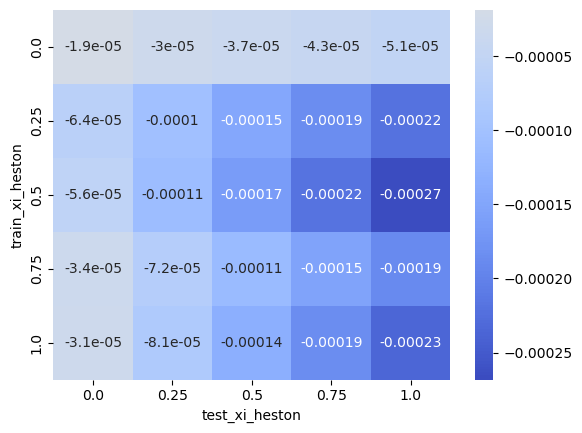

In [9]:
# Positive values mean SDH beat AADH: higher risk for AADH
risk_gap = results.pivot(
    index="train_xi_heston",
    columns="test_xi_heston",
    values="risk_diff_SDH_minus_AADH",
)
risk_gap

sns.heatmap(risk_gap, annot=True, center=0, cmap="coolwarm")
plt.show()

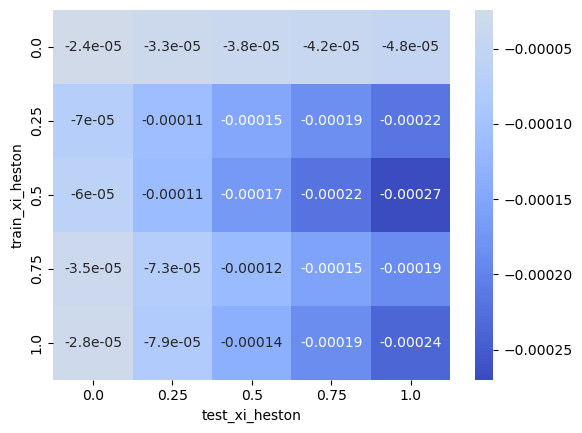

In [ ]:
# Positive values mean SDH beat AADH: higher risk for AADH
variance_gap = results.pivot(
    index="train_xi_heston",
    columns="test_xi_heston",
    values="variance_diff_SDH_minus_AADH",
)
variance_gap

sns.heatmap(variance_gap, annot=True, center=0, cmap="coolwarm")
plt.show()

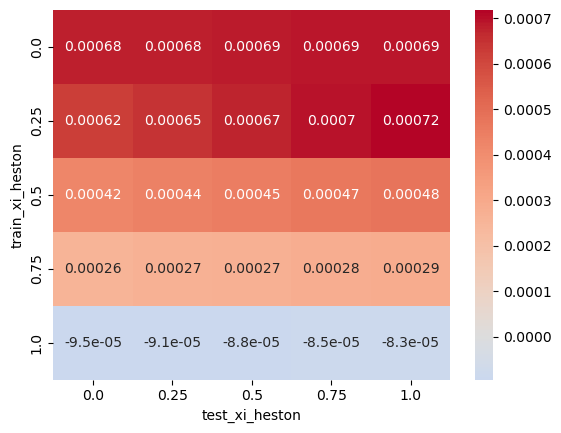

In [ ]:
# Positive values mean SDH costs more then AADH
cost_gap = results.pivot(
    index="train_xi_heston",
    columns="test_xi_heston",
    values="cost_diff_SDH_minus_AADH",
)
cost_gap

sns.heatmap(cost_gap, annot=True, center=0, cmap="coolwarm")
plt.show()